# Learned pruning on SplatFormer: opacity sparsity, or a learned mask

The threshold experiment pruned by a fixed RadSplat score of 0.01: one
hand-picked number applied to every scene, whatever the scene and whatever
the view count. This notebook trains SplatFormer to make that call itself,
in one of two ways, chosen by `PRUNING_MODE`:

**`opacity`** (the default) — no new parameters at all. The training loss
gets a sparsity term on the opacities the refiner outputs,

    total = photometric + SPARSITY_WEIGHT * mean(opacity_i)

so the refiner is paid to make Gaussians it does not need transparent, and
at inference every Gaussian whose refined opacity is at or below
`OPACITY_PRUNE_THRESHOLD` (0.005) is dropped. The photometric term renders
the refined field as it is, and a Gaussian at that opacity contributes
next to nothing to an image, so what training optimizes is what inference
keeps. The term is the sum of the opacities normalized by the count, so
that the weight means the same thing at 100k and at 500k Gaussians.

**`mask`** — the LP-3DGS route ([arXiv 2405.18784](https://arxiv.org/abs/2405.18784),
NeurIPS 2024) of the previous version of this notebook: a new head on
SplatFormer predicts, from the same per-point features the existing heads
read, a per-Gaussian offset to the log RadSplat score, binarized by a
Gumbel-Sigmoid so that it stays differentiable,

    logit_i = log(S_i) - log(SCORE_REFERENCE) + b_i + (g0 - g1)
    keep_i  = sigmoid(logit_i / TAU)
    total   = photometric + SPARSITY_WEIGHT * mean(keep_i)

with the soft mask multiplying the refined opacities during training and
its 0.5 level set dropping Gaussians at inference. The head's last layer is
zero-initialized, so the run starts at exactly the t=0.01 threshold.

Either way the pruning ratio is the model's own call, per scene and per
view count, and either way the comparison is the same: the RadSplat
threshold with its own refiner, and — the control that makes the figure
mean something — RadSplat's top-k at exactly the count the learned rule
chose for that scene, through the baseline refiner. Without that row, a
rule that simply keeps more primitives would look better for free.

The notebook has four parts:

1. **Calibration** — a short sweep over the sparsity weight, which is the
   one constant nothing already measured predicts.
2. **Training** — the real run at the chosen weight.
3. **Test-set evaluation** — the DL3DV test split, against the threshold
   baseline and against the count-matched control.
4. **Figures**.

Nothing here modifies the repository: the mask head, when there is one,
lives outside `SplatFormer.model`, so the strict checkpoint loading of the
wrapper keeps holding.

In [1]:
import gc
import json
import math
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
import sys
from contextlib import contextmanager
from collections import defaultdict
from dataclasses import dataclass, replace
from datetime import datetime
from itertools import chain
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

# The repository root, whether the notebook is opened from notebooks/ or from the root
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    assert ROOT.parent != ROOT, "Open this notebook from inside the anyprune repository"
    ROOT = ROOT.parent
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import wandb
from matplotlib.ticker import MaxNLocator
from tabulate import tabulate
from torch import Generator, Tensor
from tqdm.auto import tqdm

from anyprune.datasets import DL3DVDataset, split_scenes
from anyprune.evaluation import psnr
from anyprune.gaussians import Gaussians, blending_weights, radsplat_score
from anyprune.models import SplatFormer, build_reconstructor
from anyprune.models.utils import build_splatformer_optimizer, build_splatformer_scheduler
from anyprune.training import (
    PhotometricLoss, Reconstruction, ViewSet, plan_context_views, reconstruct,
    sample_num_context_views, sample_view_indices,
)
from anyprune.utils import load_dotenv, out_of_memory, set_rng_seed
from anyprune.viz import REFERENCE_COLOR, SERIES_COLORS
# The pieces of the training loop that do not depend on how a field is pruned
from train import ScenePrefetcher, recover_from_oom

## Hyperparameters

The constants of `configs/base.yaml`, `configs/train.yaml` and
`configs/machine/desktop.yaml`, as in the threshold notebook, plus one
block per pruning rule. The budget settings (`budget.*`) are again left
out: what a step keeps is the rule's call, not a drawn count.

In [2]:
# --- configs/base.yaml ---
SEED = 42
SPLITS = {"train": 0.8, "val": 0.1, "test": 0.1}
SPLIT_SEED = 0
COMPENSATION_EXPONENT = 1.0
ANYSPLAT_CHECKPOINT = "lhjiang/anysplat"
YONOSPLAT_CHECKPOINT = "botaoye/YoNoSplat/dl3dv_224x224_ctx2to32.ckpt"

# --- configs/machine/desktop.yaml ---
CHECKPOINTS_DIR = ROOT / "checkpoints"
OUTPUTS_DIR = ROOT / "outputs"
DL3DV_ROOT_DIR = Path("/home/nicola/Desktop/Anysplat-improved/datasets/dl3dv")
DL3DV_IMAGES_SUBDIR = "images_8"
DEVICE_MAX_GAUSSIANS = 500_000
DEVICE_MAX_VIEWS_PER_RENDER = 2
DEVICE_MAX_INTERSECTIONS = 100_000_000

# --- configs/train.yaml ---
CONTEXT_VIEWS = [2, 4, 8, 16, 24, 32, 64]
VIEW_STRIDE = 1
CONTEXT_DOWNSCALE = 1
SUPERVISION_VIEWS = "all"
SUPERVISION_MAX_VIEWS = 8
TRAINING_RECONSTRUCTOR = "YoNoSplat"
SPLATFORMER_CHECKPOINT = CHECKPOINTS_DIR / "splatformer" / "train-on-objaverse.pth"
ZERO_OUTPUT_HEADS = False
GRADIENT_CHECKPOINTING = True
LEARNING_RATES = {
    "base": 3e-5, "embedding": 3e-5, "backbone": 3e-5, "features_dc": 3e-5,
    "features_rest": 1.5e-6, "scales": 3e-5, "opacities": 3e-5, "quats": 3e-5,
    "means": 3e-5,
}
LR_SCHEDULE = "constant"
GRAD_CLIP_NORM = 2.0
L1_LOSS_WEIGHT = 1.0
L2_LOSS_WEIGHT = 0.0
LPIPS_LOSS_WEIGHT = 0.0
ENABLE_AMP = True
OOM_RETRY_FACTOR = 0.6
OOM_MAX_RETRIES = 3
PRUNING_BATCHES_PER_PASS = 32
MAX_SCORING_VIEWS = 8
VALIDATION_NUM_SCENES = 16
VALIDATION_CONTEXT_VIEWS = [6]
VALIDATION_SCORED_VIEWS = 6
LOG_INTERVAL = 5
WANDB_PROJECT = "anyprune"
# Off by default. A run interrupted part way leaves wandb's IPython hooks
# talking to a backend service that is no longer there, and from then on
# every cell of that kernel raises ConnectionResetError before its own code
# runs - wandb.init() included, so the next run cannot even start without
# restarting the kernel. What the logging was for is written to
# RUN_DIR/history.json and charted at the end of the run instead.
WANDB_MODE = "disabled"   # disabled | online | offline
DETERMINISTIC = False
# Off, so that the rule is trained and scored on the same kind of field the
# threshold baseline leaves
COMPENSATION_ENABLED = False
REFINER_BATCH_STATISTICS = True

# --- Which rule ---
# 'opacity': a sparsity term on the refined opacities, and a fixed opacity
#            cut at inference. No new parameters.
# 'mask':    the LP-3DGS style head predicting a Gumbel-Sigmoid mask over
#            the RadSplat score.
PRUNING_MODE = "opacity"
assert PRUNING_MODE in ("opacity", "mask"), PRUNING_MODE

# --- The opacity rule ---
# A Gaussian whose refined opacity is at or below this is dropped at
# inference. 0.005 is the cut 3DGS itself prunes at, so it is the floor
# of the fields the refiner was pretrained on.
OPACITY_PRUNE_THRESHOLD = 0.005
# What the loss pays per unit of mean refined opacity. From the sweep of
# 2026-09-18 (50 steps an arm, tail-averaged over the last 10; every arm
# starts at hard keep 0.74, which is what the pretrained refiner prunes
# on its own):
#
#     lambda     0.01-0.3   1.0    3.0    10     30     100
#     hard keep  0.95       0.93   0.71   0.24   0.12   0.04
#     PSNR       21.6       20.9   18.1   13.6   11.6   11.5
#
# Below 1 the term does not bite at all: the refiner un-prunes what its
# pretrained self dropped and keeps everything. 10 and above collapse the
# field. 3 is the one arm that prunes without collapsing, for about
# 3.5 dB at 50 steps, and is still drifting.
OPACITY_WEIGHT = 3.0

# --- The mask rule ---
# The score at which a Gaussian sits at keep-probability 0.5 before the head
# has learned anything. 0.01 is the threshold of the previous experiment, so
# the run starts from that cut exactly.
SCORE_REFERENCE = 0.01
# The Gumbel-Sigmoid temperature of LP-3DGS
TAU = 0.5
SCORE_EPS = 1e-12
# The head, on the same (backbone + input) features the existing heads read
MASK_HEAD_INPUT_DIM = 119
MASK_HEAD_WIDTH = 128
# A fresh head against heads that are already trained, so its own rate
MASK_LEARNING_RATE = 1e-3
# What the loss pays per unit of expected keep-fraction. From the sweep of
# 2026-09-17 (50 steps an arm, hard keep-fraction against the 0.357 the
# t=0.01 threshold starts at):
#
#     lambda    0.01    0.03    0.1     0.3     1.0
#     hard keep 0.65    0.40    0.014   0.001   0.000
#     PSNR      21.2    21.0    18.6    16.8    15.7
#
# 0.01 ends up keeping nearly twice what the fixed threshold does, and
# everything from 0.1 up collapses the field to a percent or less of what
# it was handed. The 400-step run was made at 0.01, and its test-set
# result is in the evaluation section below.
MASK_WEIGHT = 0.01

# --- What the two rules share ---
SPARSITY_WEIGHT = {"opacity": OPACITY_WEIGHT, "mask": MASK_WEIGHT}[PRUNING_MODE]
# How the per-Gaussian keep term the sparsity loss reads is named in the logs
SOFT_LABEL = {"opacity": "mean opacity", "mask": "soft keep"}[PRUNING_MODE]
RULE_LABEL = {"opacity": "opacity sparsity", "mask": "learned mask"}[PRUNING_MODE]

# --- This run ---
TOTAL_STEPS = 400
VALIDATION_INTERVAL = 100
VALIDATION_SKIP_INITIAL = False
RUN_NAME = {"opacity": f"opacity-sparsity-s{SEED}", "mask": f"learned-mask-s{SEED}"}[PRUNING_MODE]
RUN_DIR = OUTPUTS_DIR / "train" / RUN_NAME
PRUNING_CHECKPOINT = RUN_DIR / "checkpoints" / "model_final.pth"

# --- Calibration ---
# Off once the sweep has been run and the weight above is set from it.
# Turn it back on to re-derive that choice, after changing anything that
# moves the balance between the two terms of the loss.
RUN_CALIBRATION = False
CALIBRATION_WEIGHTS = {
    "opacity": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0],
    "mask": [0.01, 0.03, 0.1, 0.3, 1.0],
}[PRUNING_MODE]
CALIBRATION_STEPS = 50

# --- The baseline this is measured against ---
# The refiner of the threshold experiment: RadSplat t=0.01, 2000 steps
BASELINE_CHECKPOINT = OUTPUTS_DIR / "train" / "radsplat-t0.01-uniform-s42" / "checkpoints" / "model_final.pth"
BASELINE_THRESHOLD = 0.01

# --- Test-set evaluation (configs/eval.yaml) ---
EVAL_CONTEXT_VIEWS = [3, 6, 16, 32, 48, 64]
EVAL_GENERATORS = ["YoNoSplat"]
EVAL_NUM_SCENES = 16
EVAL_OUTPUT_DIR = OUTPUTS_DIR / {"opacity": "eval-opacity", "mask": "eval-mask"}[PRUNING_MODE]

assert 0.0 < OPACITY_PRUNE_THRESHOLD < 1.0, OPACITY_PRUNE_THRESHOLD
assert 0.0 < SCORE_REFERENCE < 1.0, SCORE_REFERENCE
assert TAU > 0.0, TAU
print(f"Pruning by {RULE_LABEL}, sparsity weight {SPARSITY_WEIGHT:g}, run {RUN_NAME}")

Pruning by opacity sparsity, sparsity weight 3, run opacity-sparsity-s42


## The two rules

Both start from the same thing: the prediction cut to the **top
`DEVICE_MAX_GAUSSIANS` by RadSplat score** — what the card can hold, and a
superset of what the 0.01 threshold would have left — refined by
SplatFormer. They differ in what says which of the refined Gaussians
survive.

**Opacity.** The refiner already has an opacity head, and its output is
what the rasterizer blends with. The sparsity term reads it directly and
the cut reads it directly; there is nothing else. `Pruned.soft` is the
opacity itself, `Pruned.hard` is `opacity > OPACITY_PRUNE_THRESHOLD`, and
the training render is the refined field untouched.

**Mask.** The six existing heads all read one `(N, 119)` tensor — the
backbone's 96 per-point channels concatenated with the 23 input channels —
and each maps it to a residual on one attribute. A **forward pre-hook** on
any one of them hands over that same tensor, which is where the mask head
plugs in without touching the model: `SplatFormer._load_weights` asserts
an exact state-dict match, and it keeps holding because the new head is
not part of `splatformer.model`. Row *i* of that tensor is Gaussian *i* of
the output, so the mask lines up with the refined attributes with no
bookkeeping. `Pruned.soft` is the Gumbel-Sigmoid mask, `Pruned.hard` is
its 0.5 level set (`logit > 0`), and the training render multiplies the
refined opacities by the soft mask.

Everything from the captured features onward runs in single precision:
Gumbel noise in half precision saturates into NaNs at this temperature.

In [3]:
class HeadInputCapture:
    """
    Hands over the (N, 119) tensor SplatFormer feeds to its output heads,
    by way of a forward pre-hook on one of them.

    The hook fires on every forward of the model, validation passes
    included, so it is only ever attached around the call whose features
    are wanted, and the capture is popped and shape-checked when it is
    taken: a tensor left over from another field would otherwise be used
    silently, and would pin that field's autograd graph.
    """

    def __init__(self, splatformer: SplatFormer, head: str = "opacities"):
        self.module = splatformer.model.features_outputhead[head]
        self.captured: Optional[Tensor] = None

    def _hook(self, module, args):
        features = args[0]
        assert features.dim() == 2 and features.shape[1] == MASK_HEAD_INPUT_DIM, (
            f"Expected the head to be fed (N, {MASK_HEAD_INPUT_DIM}), got "
            f"{tuple(features.shape)}"
        )
        self.captured = features

    @contextmanager
    def attached(self):
        handle = self.module.register_forward_pre_hook(self._hook)
        try:
            yield self
        finally:
            handle.remove()
            self.captured = None

    def take(self, num_gaussians: int) -> Tensor:
        """The features of the forward just made, once."""
        features, self.captured = self.captured, None
        assert features is not None, "The output head did not run"
        assert features.shape[0] == num_gaussians, (
            f"Captured {features.shape[0]:,} rows for {num_gaussians:,} Gaussians"
        )
        return features


class MaskHead(nn.Module):
    """
    One more output head, predicting a per-Gaussian offset to the log
    importance score, which is what decides where the pruning threshold
    falls for this Gaussian in this scene.

    The last layer starts at zero, so before any training the offset is
    zero everywhere and the mask is a smooth version of the fixed
    SCORE_REFERENCE threshold. That is deliberate, and is why the head
    needs no bias trick to start from 'keep everything': the score term
    supplies the cut. It does mean the layers before the last one see no
    gradient on the very first step - their gradient runs through
    last-layer weights that are still zero - which costs exactly one step,
    the same way SplatFormer's own zeroed heads behave.
    """

    def __init__(self, input_dim: int = MASK_HEAD_INPUT_DIM, width: int = MASK_HEAD_WIDTH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, width), nn.ReLU(),
            nn.Linear(width, width), nn.ReLU(),
            nn.Linear(width, 1),
        )
        self.net[-1].weight.data.zero_()
        self.net[-1].bias.data.zero_()

    def logits(self, features: Tensor, score: Tensor) -> Tensor:
        """
        The noiseless logit of every Gaussian: how far its score sits above
        the reference cut, in logs, plus what the head makes of it.

        In single precision whatever the caller is running in.
        """
        with torch.cuda.amp.autocast(enabled=False):
            offset = self.net(features.float()).squeeze(-1)
            log_score = score.float().clamp_min(SCORE_EPS).log()
            return log_score - math.log(SCORE_REFERENCE) + offset

    def forward(self, features: Tensor, score: Tensor) -> Tensor:
        return self.logits(features, score)


def gumbel_sigmoid(logits: Tensor, noisy: bool = True) -> Tensor:
    """
    The soft mask in [0, 1] a set of logits stands for. With 'noisy', the
    Gumbel-Sigmoid of LP-3DGS: the difference of two Gumbels is logistic
    noise, which is added before the temperature divides, and pushes the
    mask towards 0 and 1 while staying differentiable. Without it, the
    plain sigmoid, whose 0.5 level set is the hard mask.
    """
    with torch.cuda.amp.autocast(enabled=False):
        if noisy:
            uniform = torch.rand_like(logits).clamp(1e-6, 1.0 - 1e-6)
            logits = logits + uniform.log() - torch.log1p(-uniform)
        return torch.sigmoid(logits / TAU)


def scoring_views(context: ViewSet) -> ViewSet:
    """
    The context views a score is measured over during training: all of
    them, or at most MAX_SCORING_VIEWS drawn evenly along the capture.
    """
    if MAX_SCORING_VIEWS is None or len(context) <= MAX_SCORING_VIEWS:
        return context
    return context[torch.linspace(0, len(context) - 1, MAX_SCORING_VIEWS).round().long()]


@torch.no_grad()
def radsplat_scores(field: Gaussians, views: ViewSet) -> Tensor:
    """The peak blending weight of every Gaussian over 'views'."""
    return radsplat_score(blending_weights(
        field, views.poses, views.intrinsics, views.image_shape,
        batches_per_pass=PRUNING_BATCHES_PER_PASS,
        max_intersections=DEVICE_MAX_INTERSECTIONS,
    ))


def take_top(field: Gaussians, score: Tensor, num_gaussians: int) -> Tuple[Gaussians, Tensor]:
    """
    The 'num_gaussians' best-scoring Gaussians of a field and their scores,
    which is what the card can hold of a prediction and what the rule is
    then asked about. Everything below that is assumed discardable.
    """
    if field.num_gaussians <= num_gaussians:
        return field, score
    kept = torch.topk(score, num_gaussians, sorted=False).indices
    return field[kept], score[kept]


def refine(splatformer: SplatFormer, gaussians: Gaussians, enable_amp: Optional[bool] = None) -> Gaussians:
    """Run SplatFormer over a set of Gaussians, in half precision if asked."""
    with torch.cuda.amp.autocast(enabled=ENABLE_AMP if enable_amp is None else enable_amp):
        return splatformer(gaussians)


@dataclass
class Pruned:
    """
    What one forward of the refiner says about a field, under either rule.
    """
    # The refiner's output, untouched
    refined: Gaussians
    # What the photometric loss renders during training: the refined
    # field itself (opacity), or with the soft mask on its opacities (mask)
    trained: Gaussians
    # (N,) in [0, 1]: the per-Gaussian keep term the sparsity loss averages
    soft: Tensor
    # (N,) bool: what inference keeps
    hard: Tensor

    @property
    def kept(self) -> Gaussians:
        """The refined Gaussians inference keeps, never none of them."""
        keep = self.hard
        if not bool(keep.any()):
            keep = self.soft.argmax().reshape(1)
        return self.refined[keep]


def refine_and_prune(
    splatformer: SplatFormer,
    mask_head: Optional[MaskHead],
    capture: Optional[HeadInputCapture],
    field: Gaussians,
    score: Tensor,
    noisy: bool,
    enable_amp: Optional[bool] = None,
) -> Pruned:
    """
    Refine a field and read the rule off the same forward. With no mask
    head, the rule is the refined opacity; with one, the head's mask.
    """
    if mask_head is None:
        refined = refine(splatformer, field, enable_amp=enable_amp)
        opacities = refined.opacities.float()
        return Pruned(refined, refined, opacities, opacities > OPACITY_PRUNE_THRESHOLD)
    with capture.attached():
        refined = refine(splatformer, field, enable_amp=enable_amp)
        features = capture.take(field.num_gaussians)
    # Once through the head: the soft mask is a function of these logits,
    # and asking twice would build the graph twice
    logits = mask_head(features, score)
    mask = gumbel_sigmoid(logits, noisy=noisy)
    return Pruned(refined, replace(refined, opacities=refined.opacities * mask), mask, logits > 0)


def render_psnr(gaussians: Gaussians, views: ViewSet) -> float:
    rendered, _ = gaussians.rasterize(
        views.poses, views.intrinsics, views.image_shape,
        views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
        max_intersections=DEVICE_MAX_INTERSECTIONS,
    )
    return psnr(rendered, views.images).mean().item()

## Part 1: training

A step draws a scene and a context view count, reconstructs, measures the
RadSplat score over at most `MAX_SCORING_VIEWS` of the context views, keeps
the top `DEVICE_MAX_GAUSSIANS` by score, refines it, renders what the rule
says to render and takes the loss:

    total = photometric + SPARSITY_WEIGHT * mean(soft)

Neither rule drops Gaussians during training — the opacity rule makes them
transparent, the mask rule multiplies their opacities by the soft mask — so
the field keeps its size and the gradient reaches everything. The saving
shows at inference, where the hard rule drops them.

Both terms go into one scalar and one backward: with non-reentrant
gradient checkpointing the graph is freed after the first.

In [4]:
@dataclass
class StepPlan:
    """Everything one training step draws, before any of it is read."""
    scene_idx: int
    frames: Tensor
    context_idx: Tensor
    test_idx: Tensor


def training_step(
    splatformer, mask_head, capture, reconstructor, criterion, optimizer, scaler,
    scene: Dict[str, Tensor], context_idx: Tensor, test_idx: Tensor,
    generator: Generator, sparsity_weight: float, budget_scale: float = 1.0,
):
    """
    Reconstruct, cut to what the card holds, refine, apply the rule, score
    and take one optimizer step. Raises on a card that ran out of memory;
    'budget_scale' lowers the cap on a retry.
    """
    reconstruction = reconstruct(
        reconstructor, scene, context_idx, test_idx,
        generator=generator, context_downscale=CONTEXT_DOWNSCALE,
    )
    predicted = reconstruction.gaussians.num_gaussians
    cap = max(round(DEVICE_MAX_GAUSSIANS * budget_scale), 1)
    score = radsplat_scores(reconstruction.gaussians, scoring_views(reconstruction.context))
    reconstruction.gaussians, score = take_top(reconstruction.gaussians, score, cap)
    if COMPENSATION_ENABLED:
        reconstruction.gaussians = reconstruction.gaussians.compensate(
            reconstruction.gaussians.num_gaussians / predicted, exponent=COMPENSATION_EXPONENT
        )
    views = reconstruction.views(SUPERVISION_VIEWS).thin(SUPERVISION_MAX_VIEWS, generator=generator)

    pruned = refine_and_prune(
        splatformer, mask_head, capture, reconstruction.gaussians, score, noisy=True
    )
    rendered, _ = pruned.trained.rasterize(
        views.poses, views.intrinsics, views.image_shape,
        views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
    )
    photometric, terms = criterion(rendered, views.images)
    keep_fraction = pruned.soft.mean()
    # One scalar, one backward: the checkpointed graph is freed by the first
    loss = photometric + sparsity_weight * keep_fraction

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    if GRAD_CLIP_NORM > 0:
        scaler.unscale_(optimizer)
        # The mask head is not inside splatformer.parameters(), and a fresh
        # head is exactly the one that would take an unclipped first step
        torch.nn.utils.clip_grad_norm_(
            chain(splatformer.parameters(), mask_head.parameters() if mask_head is not None else ()),
            GRAD_CLIP_NORM,
        )
    scaler.step(optimizer)
    scaler.update()
    with torch.no_grad():
        # Whether the refiner pays the sparsity term in size rather than in
        # Gaussians: the same coverage at a lower opacity needs a wider footprint
        scale_ratio = (
            pruned.refined.scales.float().mean() / reconstruction.gaussians.scales.float().mean()
        ).item()
    measured = {
        "loss": loss.item(),
        "photometric": photometric.item(),
        "keep_fraction": keep_fraction.item(),
        "hard_kept": int(pruned.hard.sum().item()),
        "scale_ratio": scale_ratio,
        "num_gaussians": reconstruction.gaussians.num_gaussians,
        "predicted_gaussians": predicted,
        **terms,
    }
    return reconstruction, views, rendered.detach(), measured


@torch.no_grad()
def validate(splatformer, mask_head, capture, reconstructor, dataset, scene_indices, num_context_views: int):
    """
    Score, on the held-out views of every validation scene, the whole
    prediction, the top-DEVICE_MAX_GAUSSIANS the refiner is handed, and
    what the hard rule leaves of it after refinement.

    Views and draws come off a generator seeded by the scene alone, so
    every pass of the run scores the same thing.
    """
    was_training = splatformer.training
    splatformer.eval()
    if mask_head is not None:
        mask_head.eval()
    device = next(splatformer.parameters()).device
    scores = defaultdict(list)
    for scene_idx in tqdm(scene_indices, desc="Validating", unit="scene", leave=False):
        generator = Generator().manual_seed(SPLIT_SEED + scene_idx)
        frames, context_idx, test_idx = plan_context_views(
            dataset.num_frames(scene_idx), num_context_views, stride=VIEW_STRIDE, generator=generator,
        )
        scene = {name: value.to(device) for name, value in dataset.get_frames(scene_idx, frames).items()}
        reconstruction = field = kept = pruned = survivors = None
        try:
            reconstruction = reconstruct(
                reconstructor, scene, context_idx, test_idx,
                generator=generator, context_downscale=CONTEXT_DOWNSCALE,
            )
            for half in ("test", "context"):
                setattr(reconstruction, half, getattr(reconstruction, half).thin(
                    VALIDATION_SCORED_VIEWS, generator=Generator().manual_seed(SPLIT_SEED + scene_idx)
                ))
            field, views = reconstruction.gaussians, reconstruction.test
            predicted = field.num_gaussians
            score = radsplat_scores(field, scoring_views(reconstruction.context))
            kept, kept_score = take_top(field, score, DEVICE_MAX_GAUSSIANS)
            if COMPENSATION_ENABLED:
                kept = kept.compensate(kept.num_gaussians / predicted, exponent=COMPENSATION_EXPONENT)
            # In single precision: spconv has no half-precision kernel out of training mode
            pruned = refine_and_prune(
                splatformer, mask_head, capture, kept, kept_score, noisy=False, enable_amp=False
            )
            survivors = pruned.kept
            measured = {
                "psnr_full": render_psnr(field, views),
                "psnr_input": render_psnr(kept, views),
                "psnr_pruned": render_psnr(survivors, views),
                "predicted_gaussians": predicted,
                "input_gaussians": kept.num_gaussians,
                "num_gaussians": survivors.num_gaussians,
                "soft_keep": pruned.soft.mean().item(),
                "kept_fraction": survivors.num_gaussians / predicted,
                "rule_fraction": survivors.num_gaussians / kept.num_gaussians,
                "threshold_fraction": float((score >= BASELINE_THRESHOLD).sum().item()) / predicted,
            }
        except RuntimeError as error:
            if not out_of_memory(error):
                raise
            error.__traceback__ = None
            tqdm.write(f"  scene {scene_idx} did not fit, skipped")
            continue
        finally:
            del scene, reconstruction, field, kept, pruned, survivors
            torch.cuda.empty_cache()
        for name, value in measured.items():
            scores[name].append(value)
    splatformer.train(was_training)
    if mask_head is not None:
        mask_head.train(was_training)
    metrics = {name: sum(values) / len(values) for name, values in scores.items()}
    metrics["psnr_vs_full"] = metrics["psnr_pruned"] - metrics["psnr_full"]
    metrics["psnr_vs_input"] = metrics["psnr_pruned"] - metrics["psnr_input"]
    metrics["num_scenes"] = len(scores["psnr_pruned"])
    return metrics


def run_validation(splatformer, mask_head, capture, reconstructor, dataset, scene_indices, step: int, use_wandb: bool):
    """Validate at every count of VALIDATION_CONTEXT_VIEWS and log under val/."""
    splatformer.zero_grad(set_to_none=True)
    torch.cuda.empty_cache()
    logged = {}
    for num_context_views in VALIDATION_CONTEXT_VIEWS:
        metrics = validate(
            splatformer, mask_head, capture, reconstructor, dataset, scene_indices, num_context_views
        )
        fit = "" if metrics["num_scenes"] == len(scene_indices) else f" (over the {metrics['num_scenes']} scenes that fit)"
        tqdm.write(
            f"  [val] from {num_context_views} views the {RULE_LABEL} keeps "
            f"{metrics['num_gaussians']:,.0f} of the {metrics['input_gaussians']:,.0f} it was handed "
            f"({metrics['rule_fraction']:.1%}, {metrics['kept_fraction']:.1%} of the "
            f"{metrics['predicted_gaussians']:,.0f} predicted, against "
            f"{metrics['threshold_fraction']:.1%} for the t={BASELINE_THRESHOLD:g} threshold; "
            f"{SOFT_LABEL} {metrics['soft_keep']:.3f}): "
            f"{metrics['psnr_full']:.2f} dB whole, {metrics['psnr_input']:.2f} dB handed over, "
            f"{metrics['psnr_pruned']:.2f} dB pruned and refined "
            f"({metrics['psnr_vs_input']:+.2f} against its input, "
            f"{metrics['psnr_vs_full']:+.2f} against whole){fit}"
        )
        logged.update({
            f"val/{TRAINING_RECONSTRUCTOR}/{num_context_views}v/{name}": value
            for name, value in metrics.items()
        })
    if use_wandb:
        wandb.log(logged, step=step)
    torch.cuda.empty_cache()
    return logged

In [5]:
load_dotenv()
set_rng_seed(SEED, deterministic=DETERMINISTIC)
torch.set_float32_matmul_precision("high")
device = torch.device("cuda")

loading = tqdm(total=2, desc="Loading", unit="stage")
loading.set_postfix_str("DL3DV")
dataset = DL3DVDataset(str(DL3DV_ROOT_DIR), DL3DV_IMAGES_SUBDIR)
splits = split_scenes(len(dataset), SPLITS, SPLIT_SEED)
validation_scenes = splits["val"][:VALIDATION_NUM_SCENES]
loading.update()
tqdm.write(
    f"DL3DV initialized with {len(dataset)} scenes: "
    + ", ".join(f"{len(scenes)} {name}" for name, scenes in splits.items())
    + f", validating on {len(validation_scenes)} of them."
)
loading.set_postfix_str(f"frozen {TRAINING_RECONSTRUCTOR}")
reconstructor = build_reconstructor(TRAINING_RECONSTRUCTOR, ANYSPLAT_CHECKPOINT, YONOSPLAT_CHECKPOINT).to(device)
loading.update()
loading.close()

criterion = PhotometricLoss(l1_weight=L1_LOSS_WEIGHT, l2_weight=L2_LOSS_WEIGHT, lpips_weight=LPIPS_LOSS_WEIGHT)


def build_model(total_steps: int):
    """
    A fresh SplatFormer, with a fresh mask head if the rule wants one, and
    the optimizer, schedule and scaler to train them with.

    The mask head's parameters join the optimizer **before** the scheduler
    is built: LambdaLR takes the list of parameter groups at construction,
    and a group added afterwards is silently never scheduled. One optimizer
    for both, so that the gradient scaler unscales the head's gradients too.
    """
    splatformer = SplatFormer(
        str(SPLATFORMER_CHECKPOINT), quiet=True,
        zero_output_heads=ZERO_OUTPUT_HEADS,
        gradient_checkpointing=GRADIENT_CHECKPOINTING,
        batch_statistics=REFINER_BATCH_STATISTICS,
    ).to(device)
    splatformer.train()
    optimizer = build_splatformer_optimizer(splatformer.model, lr_dict=dict(LEARNING_RATES))
    mask_head = capture = None
    if PRUNING_MODE == "mask":
        mask_head = MaskHead().to(device)
        mask_head.train()
        capture = HeadInputCapture(splatformer)
        optimizer.add_param_group({"params": list(mask_head.parameters()), "lr": MASK_LEARNING_RATE})
    scheduler = build_splatformer_scheduler(optimizer, schedule=LR_SCHEDULE, total_step=total_steps)
    scaler = torch.cuda.amp.GradScaler(enabled=ENABLE_AMP)
    return splatformer, mask_head, capture, optimizer, scheduler, scaler


def draw_step(generator: Generator) -> StepPlan:
    """The scene a step trains on and the views it takes off it."""
    scenes = splits["train"]
    scene_idx = scenes[torch.randint(len(scenes), (1,), generator=generator).item()]
    num_context_views = sample_num_context_views(CONTEXT_VIEWS, generator=generator)
    frames, context_idx, test_idx = plan_context_views(
        dataset.num_frames(scene_idx), num_context_views, stride=VIEW_STRIDE, generator=generator,
    )
    return StepPlan(scene_idx, frames, context_idx, test_idx)


def train_run(
    total_steps: int,
    sparsity_weight: float,
    label: str,
    validation_interval: Optional[int] = None,
    use_wandb: bool = False,
    quiet: bool = False,
):
    """
    One training run, which is both what a calibration arm is and what the
    real run is: the arms differ from each other only in 'sparsity_weight',
    since every one of them rebuilds the model from the same checkpoint and
    draws its scenes off a generator seeded the same way.

    Returns the trained pieces and the per-step history.
    """
    splatformer, mask_head, capture, optimizer, scheduler, scaler = build_model(total_steps)
    generator = Generator().manual_seed(SEED)
    prefetcher = ScenePrefetcher(dataset, device)
    prefetcher.submit(draw_step(generator))
    history, oom_retries = [], 0

    progress = tqdm(range(total_steps), desc=label, unit="step", leave=not quiet)
    for step in progress:
        if validation_interval is not None and step % validation_interval == 0 and not (
            step == 0 and VALIDATION_SKIP_INITIAL
        ):
            tqdm.write(f"Validating at step {step}...")
            run_validation(
                splatformer, mask_head, capture, reconstructor, dataset,
                validation_scenes, step, use_wandb,
            )

        no_room = False
        try:
            plan, scene = prefetcher.take()
        except RuntimeError as error:
            if not out_of_memory(error):
                raise
            no_room = True
        if no_room:
            tqdm.write(f"Step {step}: no room to read a scene in, clearing")
            recover_from_oom(optimizer, scaler)
            plan, scene = prefetcher.take()
        if step + 1 < total_steps:
            prefetcher.submit(draw_step(generator))

        step_result, budget_scale = None, 1.0
        for attempt in range(OOM_MAX_RETRIES + 1):
            ran_out = False
            try:
                step_result = training_step(
                    splatformer, mask_head, capture, reconstructor, criterion,
                    optimizer, scaler, scene, plan.context_idx, plan.test_idx,
                    generator, sparsity_weight, budget_scale=budget_scale,
                )
                break
            except RuntimeError as error:
                if not out_of_memory(error):
                    raise
                ran_out = True
            # Recovered out here rather than in the handler, which would still
            # hold the frames of the failed step and with them its autograd graph
            if ran_out:
                recover_from_oom(optimizer, scaler)
                oom_retries += 1
                budget_scale *= OOM_RETRY_FACTOR
                if attempt < OOM_MAX_RETRIES:
                    tqdm.write(
                        f"Step {step}: out of memory, retrying scene {plan.scene_idx} with the cap at "
                        f"{round(DEVICE_MAX_GAUSSIANS * budget_scale):,} ({attempt + 1}/{OOM_MAX_RETRIES})"
                    )
        if step_result is None:
            tqdm.write(f"Step {step}: skipped, scene {plan.scene_idx} did not fit")
            del scene
            continue
        reconstruction, views, rendered, measured = step_result
        scheduler.step()

        with torch.no_grad():
            unpruned, _ = reconstruction.gaussians.rasterize(
                views.poses, views.intrinsics, views.image_shape,
                views_per_pass=DEVICE_MAX_VIEWS_PER_RENDER,
            )
        psnr_input = psnr(unpruned, views.images).mean().item()
        psnr_refined = psnr(rendered, views.images).mean().item()
        record = {
            "step": step, "sparsity_weight": sparsity_weight,
            "context_views": len(plan.context_idx),
            "supervision_views": len(views),
            "psnr_input": psnr_input, "psnr_refined": psnr_refined,
            "psnr_gain": psnr_refined - psnr_input,
            "oom_retries": oom_retries,
            "memory_peak_gib": torch.cuda.max_memory_allocated() / 2 ** 30,
            **measured,
        }
        record["hard_fraction"] = record["hard_kept"] / record["num_gaussians"]
        history.append(record)

        if step % LOG_INTERVAL == 0:
            if use_wandb:
                wandb.log({f"train/{name}": value for name, value in record.items()}, step=step)
            progress.set_postfix(
                loss=f"{record['loss']:.4f}",
                keep=f"{record['hard_fraction']:.2f}",
                gain=f"{record['psnr_gain']:+.2f}",
            )
            if not quiet:
                tqdm.write(
                    f"Step {step}: loss {record['loss']:.4f} "
                    f"({record['photometric']:.4f} photometric), PSNR "
                    f"{psnr_input:.2f} -> {psnr_refined:.2f} dB, {SOFT_LABEL} "
                    f"{record['keep_fraction']:.3f}, hard keep {record['hard_fraction']:.3f} "
                    f"({record['hard_kept']:,} of {record['num_gaussians']:,} handed over, "
                    f"{record['predicted_gaussians']:,} predicted) from "
                    f"{record['context_views']} context views, scales x{record['scale_ratio']:.2f}, peak "
                    f"{record['memory_peak_gib']:.1f} GiB"
                )
        del step_result, reconstruction, views, rendered, scene

    progress.close()
    prefetcher.close()
    return splatformer, mask_head, capture, history

Loading:   0%|          | 0/2 [00:00<?, ?stage/s]

DL3DV initialized with 541 scenes: 433 train, 54 val, 54 test, validating on 16 of them.


### Calibration: sizing the sparsity weight

`SPARSITY_WEIGHT` is the one constant nothing already measured predicts:
too small and the rule keeps everything, too large and it prunes the scene
away, and the usable decade depends on how the photometric loss and the
sparsity term happen to scale against each other — which differs between
the two rules, since the opacity term moves through the refiner's own
heads at their own learning rate while the mask head has a rate of its
own, thirty times higher.

Each arm below rebuilds the model from the same checkpoint and draws the
same scenes in the same order, so they differ only in the weight. What
this sizes is the **order of magnitude, not the final ratio**: fifty steps
show the initial drift, and a weight that looks gentle here can still walk
much further by step `TOTAL_STEPS`.

**Mask rule** (run 2026-09-17, 50 steps an arm; hard keep-fraction against
the 0.357 the t=0.01 threshold starts every arm at):

| lambda | soft keep | hard keep | PSNR | vs its input |
|---|---|---|---|---|
| 0.01 | 0.544 | 0.652 | 21.18 dB | -0.70 |
| 0.03 | 0.453 | 0.401 | 20.95 dB | -0.93 |
| 0.1 | 0.137 | 0.014 | 18.60 dB | -3.29 |
| 0.3 | 0.042 | 0.001 | 16.75 dB | -5.13 |
| 1.0 | 0.022 | 0.000 | 15.69 dB | -6.19 |

The useful range is narrow and the edge of it is sharp: at 0.01 the mask
keeps nearly twice what the fixed threshold does, by 0.1 the field
collapses to 1.4% of what it was handed.

**Opacity rule** (run 2026-09-18, 50 steps an arm, in two passes since
the first found nothing that pruned; tail-averaged over the last 10
steps):

| lambda | mean opacity | hard keep | PSNR | vs its input | peak GiB |
|---|---|---|---|---|---|
| 0.01 | 0.051 | 0.948 | 21.60 dB | -0.29 | 13.4 |
| 0.03 | 0.052 | 0.950 | 21.68 dB | -0.20 | 13.4 |
| 0.1 | 0.044 | 0.948 | 21.70 dB | -0.18 | 13.4 |
| 0.3 | 0.035 | 0.945 | 21.50 dB | -0.38 | 13.5 |
| 1.0 | 0.024 | 0.927 | 20.85 dB | -1.04 | 13.5 |
| **3.0** | **0.011** | **0.706** | **18.14 dB** | **-3.75** | **14.4** |
| 10 | 0.007 | 0.240 | 13.55 dB | -7.54 | 14.4, 12 OOM retries |
| 30 | 0.002 | 0.117 | 11.61 dB | -6.29 | 14.4, 41 OOM retries |
| 100 | 0.001 | 0.037 | 11.50 dB | -6.79 | 14.4, 46 OOM retries |

Three things this says. First, **the pretrained refiner already prunes**:
every arm starts at hard keep 0.74, a quarter of what it is handed put
under 0.005 by SplatFormer as it comes out of the box, and within ten
steps of photometric training that quarter is back — the first thing
fine-tuning does is un-prune. Second, the refined opacities are low
across the board (a mean of 0.05, YoNoSplat's fields being that diffuse),
so the sigmoid gradient on each of them is small and the term needs a
weight two decades above the mask's before it moves anything through
heads that learn at 3e-5. Third, from 10 up the runs start running out
of memory on scenes that fit every other arm, with the field unchanged in
count; the likely reading is that the refiner pays the opacity bill by
inflating scales — the same coverage at a lower opacity — and the tile
intersections go up with it. The run below records the ratio of refined
to input scales to check that.

**3.0** is the choice: the one weight that prunes without collapsing.

In [6]:
calibration = {}
if RUN_CALIBRATION:
    for weight in tqdm(CALIBRATION_WEIGHTS, desc="Calibrating", unit="arm"):
        splatformer, mask_head, capture, history = train_run(
            CALIBRATION_STEPS, weight, label=f"lambda={weight:g}", quiet=True,
        )
        calibration[weight] = history
        last = history[-1]
        # Freed before the next arm builds its own model, not after
        del splatformer, mask_head, capture
        gc.collect()
        torch.cuda.empty_cache()
        tqdm.write(
            f"lambda={weight:<6g} ended at {SOFT_LABEL} {last['keep_fraction']:.3f}, hard keep "
            f"{last['hard_fraction']:.3f}, PSNR {last['psnr_refined']:.2f} dB "
            f"({last['psnr_gain']:+.2f} over its input)"
        )

    rows = []
    for weight, history in calibration.items():
        tail = history[-max(1, len(history) // 5):]
        rows.append([
            f"{weight:g}",
            f"{history[0]['hard_fraction']:.3f}",
            f"{sum(r['keep_fraction'] for r in tail) / len(tail):.3f}",
            f"{sum(r['hard_fraction'] for r in tail) / len(tail):.3f}",
            f"{sum(r['psnr_refined'] for r in tail) / len(tail):.2f}",
            f"{sum(r['psnr_gain'] for r in tail) / len(tail):+.2f}",
        ])
    print(tabulate(rows, headers=[
        "lambda", "hard @0", SOFT_LABEL, "hard keep", "PSNR", "vs input"
    ], tablefmt="simple"))

    figure, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    for index, (weight, history) in enumerate(calibration.items()):
        color = SERIES_COLORS[index % len(SERIES_COLORS)]
        steps = [r["step"] for r in history]
        axes[0].plot(steps, [r["keep_fraction"] for r in history], color=color,
                     linewidth=1.6, label=f"lambda={weight:g}")
        axes[1].plot(steps, [r["hard_fraction"] for r in history], color=color, linewidth=1.6)
        axes[2].plot(steps, [r["psnr_refined"] for r in history], color=color, linewidth=1.6)
    for axis, label in zip(axes, (SOFT_LABEL, "hard keep-fraction", "PSNR of the pruned field (dB)")):
        axis.set_xlabel("step")
        axis.set_title(label, fontsize=10, loc="left")
        axis.grid(axis="y", color="#e5e5e5", linewidth=0.8)
        for side in ("top", "right"):
            axis.spines[side].set_visible(False)
    axes[0].set_ylim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[0].legend(frameon=False, fontsize=8)
    figure.suptitle(
        f"Sizing the sparsity weight of the {RULE_LABEL} over {CALIBRATION_STEPS} steps",
        x=0.01, ha="left", fontsize=11,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    figure.savefig(RUN_DIR / "calibration.png", dpi=150, bbox_inches="tight")
    (RUN_DIR / "calibration.json").write_text(json.dumps(
        {str(weight): arm for weight, arm in calibration.items()}, indent=2
    ))
    print(f"Wrote {RUN_DIR / 'calibration.png'} and calibration.json")
    plt.show()

### The run

`SPARSITY_WEIGHT` is set from the sweep above, so this runs as it stands.
The training record carries `scale_ratio`, the mean refined scale over
the mean input scale, which is what says whether the opacity term is being
paid in scale rather than in Gaussians.

One thing the mask run showed, over its first 50 steps: the ratio the rule
picks varies a lot with the context view count — around 0.23-0.33 at 8 and
16 views, but 0.011 at 64, where the top-500k of a 3.2-million-Gaussian
prediction is already a poor reconstruction (12.5 dB before pruning) and
the sparsity term has little quality left to trade against. That spread is
the scene-adaptive behaviour the experiment is after, but the 64-view end
is worth watching: a field cut to 5,000 Gaussians is a different claim from
one cut to a third.

Training:   0%|          | 0/400 [00:00<?, ?step/s]

Validating at step 0...


Validating:   0%|          | 0/16 [00:00<?, ?scene/s]

  [val] from 6 views the opacity sparsity keeps 241,525 of the 301,056 it was handed (80.2%, 80.2% of the 301,056 predicted, against 37.9% for the t=0.01 threshold; mean opacity 0.085): 26.53 dB whole, 26.53 dB handed over, 16.60 dB pruned and refined (-9.93 against its input, -9.93 against whole)


/home/nicola/miniconda3/envs/anyprune/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


...

Step 390: loss 0.0883 (0.0751 photometric), PSNR 21.29 -> 19.00 dB, mean opacity 0.004, hard keep 0.262 (131,105 of 500,000 handed over, 1,204,224 predicted) from 24 context views, scales x3.71, peak 14.4 GiB


Step 395: loss 0.1345 (0.1182 photometric), PSNR 20.59 -> 15.48 dB, mean opacity 0.005, hard keep 0.356 (178,090 of 500,000 handed over, 1,204,224 predicted) from 24 context views, scales x4.22, peak 14.4 GiB


Validating:   0%|          | 0/16 [00:00<?, ?scene/s]

  [val] from 6 views the opacity sparsity keeps 102,698 of the 301,056 it was handed (34.1%, 34.1% of the 301,056 predicted, against 37.9% for the t=0.01 threshold; mean opacity 0.005): 26.53 dB whole, 26.53 dB handed over, 19.66 dB pruned and refined (-6.86 against its input, -6.86 against whole)
Wrote /home/nicola/Desktop/anyprune/outputs/train/opacity-sparsity-s42/history.json
Wrote /home/nicola/Desktop/anyprune/outputs/train/opacity-sparsity-s42/checkpoints/model_final.pth


Wrote /home/nicola/Desktop/anyprune/outputs/train/opacity-sparsity-s42/training.png


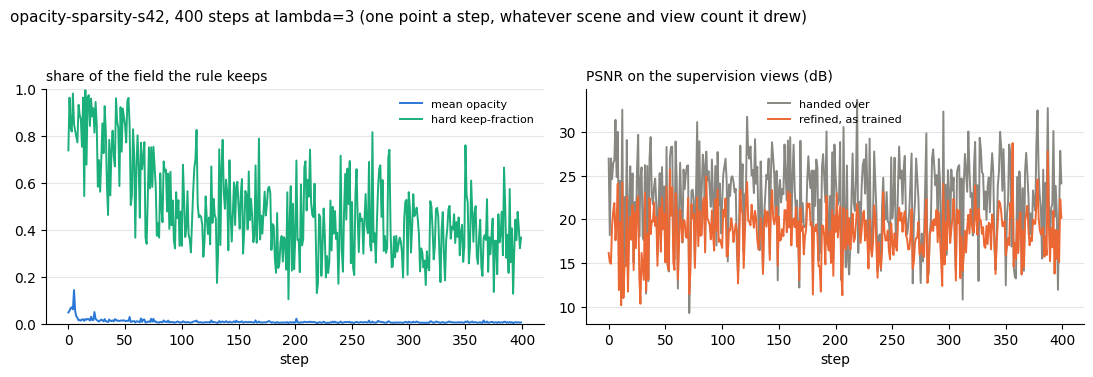

In [7]:
hyperparameters = {
    name: (str(value) if isinstance(value, Path) else value)
    for name, value in dict(globals()).items()
    if name.isupper() and isinstance(value, (bool, int, float, str, list, dict, Path, type(None)))
}
USE_WANDB = WANDB_MODE != "disabled"
if USE_WANDB:
    run = wandb.init(
        project=WANDB_PROJECT, mode=WANDB_MODE, name=RUN_NAME, config=hyperparameters,
        notes=(
            f"{RULE_LABEL} on top of SplatFormer, sparsity weight {SPARSITY_WEIGHT:g}"
            + (
                f", Gumbel-Sigmoid at tau={TAU:g} over the RadSplat score with reference {SCORE_REFERENCE:g}"
                if PRUNING_MODE == "mask" else f", opacity cut at {OPACITY_PRUNE_THRESHOLD:g}"
            )
        ),
        settings=wandb.Settings(x_disable_stats=True),
    )
PRUNING_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)

splatformer, mask_head, capture, history = train_run(
    TOTAL_STEPS, SPARSITY_WEIGHT, label="Training",
    validation_interval=VALIDATION_INTERVAL, use_wandb=USE_WANDB,
)
run_validation(
    splatformer, mask_head, capture, reconstructor, dataset, validation_scenes,
    TOTAL_STEPS, USE_WANDB,
)
# Written whether or not anything was logging: this is the run's own record
# of what the rule did, step by step
(RUN_DIR / "history.json").write_text(json.dumps(
    {"hyperparameters": hyperparameters, "history": history}, indent=2
))
print(f"Wrote {RUN_DIR / 'history.json'}")
torch.save({
    "splatformer": splatformer.model.state_dict(),
    "pruning_mode": PRUNING_MODE,
    "sparsity_weight": SPARSITY_WEIGHT,
    "opacity_threshold": OPACITY_PRUNE_THRESHOLD,
    "mask_head": mask_head.state_dict() if mask_head is not None else None,
    "score_reference": SCORE_REFERENCE,
    "tau": TAU,
}, PRUNING_CHECKPOINT)
print(f"Wrote {PRUNING_CHECKPOINT}")
if USE_WANDB:
    wandb.finish()

figure, axes = plt.subplots(1, 2, figsize=(11, 3.8))
steps = [r["step"] for r in history]
axes[0].plot(steps, [r["keep_fraction"] for r in history],
             color=SERIES_COLORS[0], linewidth=1.4, label=SOFT_LABEL)
axes[0].plot(steps, [r["hard_fraction"] for r in history],
             color=SERIES_COLORS[2], linewidth=1.4, label="hard keep-fraction")
axes[0].set_ylim(0, 1)
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(steps, [r["psnr_input"] for r in history],
             color=REFERENCE_COLOR, linewidth=1.4, label="handed over")
axes[1].plot(steps, [r["psnr_refined"] for r in history],
             color=SERIES_COLORS[1], linewidth=1.4, label="refined, as trained")
axes[1].legend(frameon=False, fontsize=8)
for axis, label in zip(axes, (
    "share of the field the rule keeps", "PSNR on the supervision views (dB)"
)):
    axis.set_xlabel("step")
    axis.set_title(label, fontsize=10, loc="left")
    axis.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
figure.suptitle(
    f"{RUN_NAME}, {TOTAL_STEPS} steps at lambda={SPARSITY_WEIGHT:g} "
    f"(one point a step, whatever scene and view count it drew)",
    x=0.01, ha="left", fontsize=11,
)
figure.tight_layout(rect=(0, 0, 1, 0.94))
figure.savefig(RUN_DIR / "training.png", dpi=150, bbox_inches="tight")
print(f"Wrote {RUN_DIR / 'training.png'}")
plt.show()

## Part 2: test-set evaluation

The protocol of `scripts/eval.py`: every test scene is a window of
`2 * max(EVAL_CONTEXT_VIEWS)` contiguous frames, alternating context and
test frames; at each view count the generator predicts a field from the
first frames of the window, and every method is scored on the context views
(self-reconstruction) and on the test views between them (novel view
synthesis). The score is measured once per scene over **every** context
view and every method reads it.

Five methods:

| Method | What it is |
|---|---|
| full field | the whole prediction, the ceiling |
| RadSplat t=0.01 | the previous experiment's input, no refiner |
| RadSplat t=0.01 + SplatFormer | the previous experiment's headline, its own trained refiner |
| *rule* + SplatFormer | this run; the count is the rule's own call, per scene |
| RadSplat top-k matched + SplatFormer | the baseline refiner on the top-k by score, at exactly the count the rule chose for that scene |

The last row is the control that makes the figure mean something: without
it, a rule that simply keeps more primitives would look better for free.

This part runs on its own once `PRUNING_CHECKPOINT` exists.

**What the mask rule came to** (400 steps at lambda=0.01, evaluated
2026-09-18 on 16 test scenes, NVS PSNR): it landed at the threshold's own
ratio at every view count (47% of the prediction at 3 views, 38% at 6, 25%
at 16, down to 10% at 64), and at every one of them it lost to the
count-matched top-k through the baseline refiner — by 0.7 dB at 3 views,
1.1 at 6, 2.9 at 16, 2.9 at 32, 2.7 at 48 and 1.7 at 64. A head that
starts at the threshold and learns per-Gaussian deviations from it found
no deviation worth having, and the refiner trained under a noisy soft mask
came out worse than one trained on a hard cut. That is the bar the opacity
rule is measured against.

In [8]:
for name in ("splatformer", "mask_head", "capture", "optimizer", "scaler", "scheduler", "reconstructor"):
    globals().pop(name, None)
gc.collect()
torch.cuda.empty_cache()

load_dotenv()
set_rng_seed(SEED, deterministic=DETERMINISTIC)
torch.set_float32_matmul_precision("high")
device = torch.device("cuda")
assert PRUNING_CHECKPOINT.exists(), f"No trained model at {PRUNING_CHECKPOINT}: train it above"
assert BASELINE_CHECKPOINT.exists(), f"No baseline refiner at {BASELINE_CHECKPOINT}"

loading = tqdm(total=3, desc="Loading", unit="stage")
loading.set_postfix_str("DL3DV")
dataset = DL3DVDataset(str(DL3DV_ROOT_DIR), DL3DV_IMAGES_SUBDIR)
test_scenes = split_scenes(len(dataset), SPLITS, SPLIT_SEED)["test"]
if EVAL_NUM_SCENES is not None:
    test_scenes = test_scenes[:EVAL_NUM_SCENES]
loading.update()

loading.set_postfix_str(f"{RULE_LABEL} refiner")
checkpoint = torch.load(PRUNING_CHECKPOINT, map_location="cpu")
assert checkpoint.get("pruning_mode", "mask") == PRUNING_MODE, (
    f"{PRUNING_CHECKPOINT} was trained under the {checkpoint.get('pruning_mode', 'mask')} rule, "
    f"the notebook is set to {PRUNING_MODE}"
)
learned_refiner = SplatFormer(None, quiet=True, batch_statistics=REFINER_BATCH_STATISTICS).to(device)
learned_refiner.model.load_state_dict(checkpoint["splatformer"])
learned_refiner.eval()
mask_head = capture = None
if PRUNING_MODE == "mask":
    mask_head = MaskHead().to(device)
    mask_head.load_state_dict(checkpoint["mask_head"])
    mask_head.eval()
    capture = HeadInputCapture(learned_refiner)
loading.update()

loading.set_postfix_str(f"baseline {BASELINE_CHECKPOINT.name}")
baseline_refiner = SplatFormer(
    str(BASELINE_CHECKPOINT), quiet=True, batch_statistics=REFINER_BATCH_STATISTICS
).to(device).eval()
loading.update()
loading.close()
print(
    f"{RULE_LABEL} refiner trained at lambda={checkpoint['sparsity_weight']:g}"
    + (
        f", reference {checkpoint['score_reference']:g}, tau={checkpoint['tau']:g}"
        if PRUNING_MODE == "mask" else f", opacity cut at {checkpoint['opacity_threshold']:g}"
    )
)

METHOD_FULL = "full field"
METHOD_THRESHOLD = f"RadSplat t={BASELINE_THRESHOLD:g}"
METHOD_THRESHOLD_REFINED = f"RadSplat t={BASELINE_THRESHOLD:g} + SplatFormer"
METHOD_LEARNED = f"{RULE_LABEL} + SplatFormer"
METHOD_MATCHED = "RadSplat top-k matched + SplatFormer"
METHODS = [METHOD_FULL, METHOD_THRESHOLD, METHOD_THRESHOLD_REFINED, METHOD_LEARNED, METHOD_MATCHED]
BLOCKS = (("self", "context"), ("nvs", "test"))


def score_halves(gaussians: Gaussians, reconstruction: Reconstruction) -> Dict[str, float]:
    """Mean PSNR of a field on each half of the scene."""
    return {f"{block}_psnr": render_psnr(gaussians, getattr(reconstruction, half)) for block, half in BLOCKS}


@torch.no_grad()
def evaluate_scene(reconstructor, scene, context_idx, test_idx) -> List[dict]:
    """
    Every method on one scene at one view count, off a single measurement
    of the RadSplat score over all the context views.

    A method that does not fit is left out of that cell rather than ending
    the scene, so a field too wide for a refiner still counts everywhere
    else; the matched control is only ever run once the rule has said how
    many Gaussians it keeps.
    """
    reconstruction = reconstruct(reconstructor, scene, context_idx, test_idx)
    field, context = reconstruction.gaussians, reconstruction.context
    predicted = field.num_gaussians
    score = radsplat_scores(field, context)

    records = [{"method": METHOD_FULL, "num_gaussians": predicted, **score_halves(field, reconstruction)}]

    # The previous experiment's rule, and its own refiner
    above = torch.nonzero(score >= BASELINE_THRESHOLD).squeeze(1)
    if above.numel() == 0:
        above = score.argmax().reshape(1)
    thresholded = field[above]
    records.append({
        "method": METHOD_THRESHOLD, "num_gaussians": thresholded.num_gaussians,
        **score_halves(thresholded, reconstruction),
    })
    try:
        # spconv has no half-precision kernels out of training mode
        with torch.cuda.amp.autocast(enabled=False):
            refined = baseline_refiner(thresholded)
        records.append({
            "method": METHOD_THRESHOLD_REFINED, "num_gaussians": refined.num_gaussians,
            **score_halves(refined, reconstruction),
        })
        del refined
    except RuntimeError as error:
        if not out_of_memory(error):
            raise
        error.__traceback__ = None
        torch.cuda.empty_cache()
        tqdm.write(f"  {thresholded.num_gaussians:,} Gaussians did not fit the baseline refiner, skipped")
    del thresholded

    # This experiment: the top of what the card holds, refined and pruned
    handed, handed_score = take_top(field, score, DEVICE_MAX_GAUSSIANS)
    if COMPENSATION_ENABLED:
        handed = handed.compensate(handed.num_gaussians / predicted, exponent=COMPENSATION_EXPONENT)
    kept = None
    try:
        with torch.cuda.amp.autocast(enabled=False):
            pruned = refine_and_prune(
                learned_refiner, mask_head, capture, handed, handed_score,
                noisy=False, enable_amp=False,
            )
        survivors = pruned.kept
        kept = survivors.num_gaussians
        records.append({
            "method": METHOD_LEARNED, "num_gaussians": kept,
            "input_gaussians": handed.num_gaussians,
            "soft_keep": pruned.soft.mean().item(),
            **score_halves(survivors, reconstruction),
        })
        del pruned, survivors
    except RuntimeError as error:
        if not out_of_memory(error):
            raise
        error.__traceback__ = None
        torch.cuda.empty_cache()
        tqdm.write(f"  {handed.num_gaussians:,} Gaussians did not fit the {RULE_LABEL} refiner, skipped")
    del handed

    # The control: the same count, taken straight off the score, through the
    # baseline refiner
    if kept is not None:
        try:
            matched, _ = take_top(field, score, kept)
            if COMPENSATION_ENABLED:
                matched = matched.compensate(matched.num_gaussians / predicted, exponent=COMPENSATION_EXPONENT)
            assert matched.num_gaussians == kept, (
                f"The control kept {matched.num_gaussians:,} against the rule's {kept:,}"
            )
            with torch.cuda.amp.autocast(enabled=False):
                refined = baseline_refiner(matched)
            records.append({
                "method": METHOD_MATCHED, "num_gaussians": refined.num_gaussians,
                **score_halves(refined, reconstruction),
            })
            del matched, refined
        except RuntimeError as error:
            if not out_of_memory(error):
                raise
            error.__traceback__ = None
            torch.cuda.empty_cache()
            tqdm.write(f"  the {kept:,}-Gaussian control did not fit, skipped")

    del field, score
    return [{"context_views": len(context_idx), "predicted_gaussians": predicted, **record} for record in records]


AVERAGED = ("num_gaussians", "predicted_gaussians", "self_psnr", "nvs_psnr")


def summarize(records: List[dict]) -> List[dict]:
    """The mean over the scenes of every (generator, view count, method) cell."""
    groups = defaultdict(list)
    for record in records:
        groups[(record["generator"], record["context_views"], record["method"])].append(record)
    return [
        {
            "generator": generator, "context_views": views, "method": method, "num_scenes": len(group),
            **{key: sum(r[key] for r in group) / len(group) for key in AVERAGED},
        }
        for (generator, views, method), group in groups.items()
    ]

Loading:   0%|          | 0/3 [00:00<?, ?stage/s]

opacity sparsity refiner trained at lambda=3, opacity cut at 0.005


In [9]:
output_dir = EVAL_OUTPUT_DIR / datetime.now().strftime("%Y%m%d-%H%M%S")
output_dir.mkdir(parents=True, exist_ok=True)
window = 2 * max(EVAL_CONTEXT_VIEWS)
print(
    f"Evaluating {len(test_scenes)} scenes of the DL3DV test split on windows of {window} frames, "
    f"from {EVAL_CONTEXT_VIEWS} context views, through {', '.join(EVAL_GENERATORS)}. "
    f"Writing to {output_dir}"
)

records = []
for generator_name in tqdm(EVAL_GENERATORS, desc="Generators", unit="generator", disable=len(EVAL_GENERATORS) == 1):
    reconstructor = build_reconstructor(generator_name, ANYSPLAT_CHECKPOINT, YONOSPLAT_CHECKPOINT).to(device)
    for scene_idx in tqdm(test_scenes, desc=generator_name, unit="scene"):
        seed = SEED + scene_idx
        frames, context_idx, test_idx = sample_view_indices(
            dataset.num_frames(scene_idx), window, generator=Generator().manual_seed(seed),
        )
        scene = {name: value.to(device) for name, value in dataset.get_frames(scene_idx, frames).items()}
        sweep = tqdm(EVAL_CONTEXT_VIEWS, desc=f"  scene {scene_idx}", unit="count", leave=False)
        for views in sweep:
            sweep.set_postfix_str(f"{views} views")
            try:
                measured = evaluate_scene(reconstructor, scene, context_idx[:views], test_idx[:views])
            except RuntimeError as error:
                if not out_of_memory(error):
                    raise
                error.__traceback__ = None
                measured = []
                tqdm.write(f"  scene {scene_idx} did not fit at {views} context views through {generator_name}, skipped")
            torch.cuda.empty_cache()
            records += [{"scene": scene_idx, "generator": generator_name, **record} for record in measured]
            learned = [r for r in measured if r["method"] == METHOD_LEARNED]
            if learned:
                sweep.set_postfix_str(
                    f"{views} views, {RULE_LABEL} kept {learned[0]['num_gaussians']:,} of "
                    f"{learned[0]['input_gaussians']:,}"
                )
        sweep.close()
        del scene
        (output_dir / "results.json").write_text(json.dumps({
            "hyperparameters": hyperparameters if "hyperparameters" in globals() else None,
            "pruning_mode": PRUNING_MODE,
            "learned_checkpoint": str(PRUNING_CHECKPOINT),
            "baseline_checkpoint": str(BASELINE_CHECKPOINT),
            "scenes": [Path(dataset.scenes[idx]).name for idx in test_scenes],
            "records": records,
            "summary": summarize(records),
        }, indent=2))
    del reconstructor
    gc.collect()
    torch.cuda.empty_cache()

summary = summarize(records)
for generator_name in EVAL_GENERATORS:
    rows = [
        [r["context_views"], r["method"], r["num_scenes"], f"{r['predicted_gaussians']:,.0f}",
         f"{r['num_gaussians']:,.0f}", f"{r['num_gaussians'] / r['predicted_gaussians']:.1%}",
         f"{r['self_psnr']:.2f}", f"{r['nvs_psnr']:.2f}"]
        for views in EVAL_CONTEXT_VIEWS for method in METHODS
        for r in summary if r["generator"] == generator_name and r["context_views"] == views and r["method"] == method
    ]
    print(f"\n{generator_name}, {len(test_scenes)} test scenes\n")
    print(tabulate(rows, headers=[
        "views", "method", "scenes", "predicted", "kept", "share", "PSNR self", "PSNR NVS"
    ], tablefmt="simple"))

Evaluating 16 scenes of the DL3DV test split on windows of 128 frames, from [3, 6, 16, 32, 48, 64] context views, through YoNoSplat. Writing to /home/nicola/Desktop/anyprune/outputs/eval-opacity/20260918-215306


YoNoSplat:   0%|          | 0/16 [00:00<?, ?scene/s]

  scene 367:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 381:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 372:   0%|          | 0/6 [00:00<?, ?count/s]

...

  scene 131:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 3:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 57:   0%|          | 0/6 [00:00<?, ?count/s]

  scene 113:   0%|          | 0/6 [00:00<?, ?count/s]


YoNoSplat, 16 test scenes

  views  method                                  scenes    predicted       kept  share      PSNR self    PSNR NVS
-------  ------------------------------------  --------  -----------  ---------  -------  -----------  ----------
      3  full field                                  16      150,528    150,528  100.0%         26.31       25.92
      3  RadSplat t=0.01                             16      150,528     70,693  47.0%          23.46       23.16
      3  RadSplat t=0.01 + SplatFormer               16      150,528     70,693  47.0%          26.94       26.46
      3  opacity sparsity + SplatFormer              16      150,528     63,205  42.0%          19.63       19.58
      3  RadSplat top-k matched + SplatFormer        16      150,528     63,205  42.0%          26.71       26.3
      6  full field                                  16      301,056    301,056  100.0%         27.16       26.89
      6  RadSplat t=0.01                             16      

## Part 3: figures

One row per generator: PSNR on the context views and on the held-out ones,
how many primitives each method keeps, the share of the prediction the rule
decided to keep against the fixed threshold's share, and how many test
scenes each cell averages over.

Wrote /home/nicola/Desktop/anyprune/outputs/eval-opacity/20260918-215306/pruning_eval_yonosplat.png


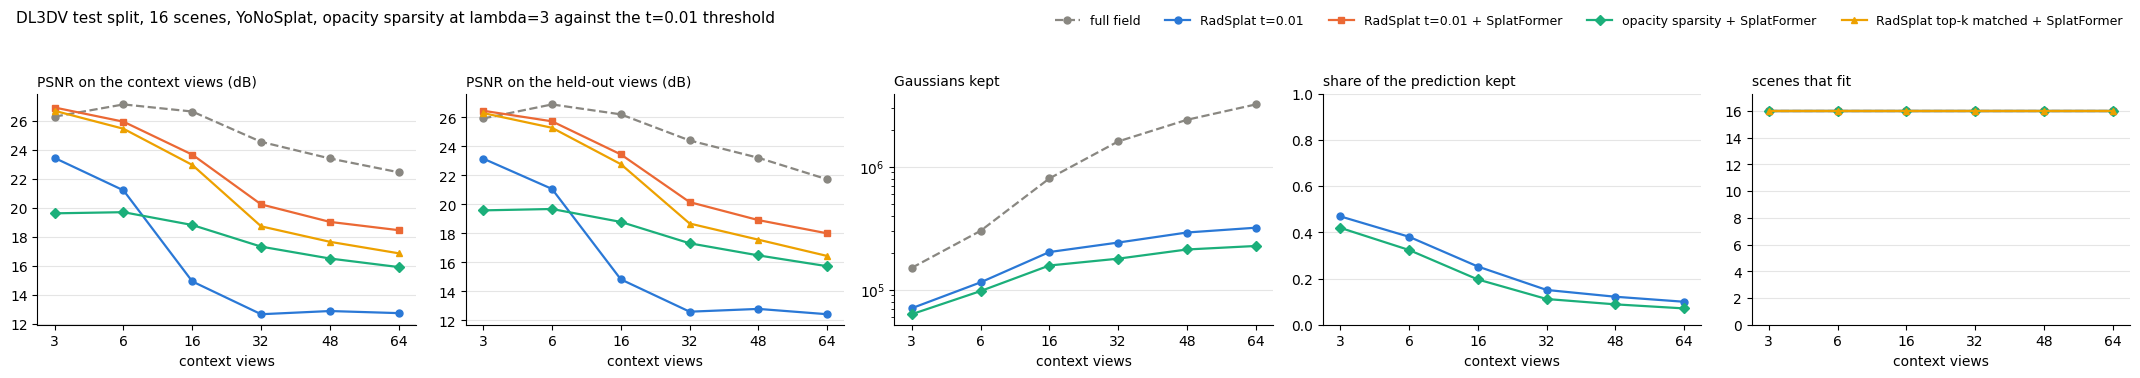

In [10]:
def plot_pruning_eval(summary: List[dict], generator_name: str, title: str):
    """
    Every method against the context view count: PSNR on both halves of the
    scene, the primitives kept, what share of the prediction that is, and
    the scenes that fit.
    """
    cells = {(r["context_views"], r["method"]): r for r in summary if r["generator"] == generator_name}
    views = [v for v in EVAL_CONTEXT_VIEWS if any((v, m) in cells for m in METHODS)]
    positions = list(range(len(views)))
    styles = {
        METHOD_FULL: dict(color=REFERENCE_COLOR, linestyle="--", marker="o"),
        METHOD_THRESHOLD: dict(color=SERIES_COLORS[0], marker="o"),
        METHOD_THRESHOLD_REFINED: dict(color=SERIES_COLORS[1], marker="s"),
        METHOD_LEARNED: dict(color=SERIES_COLORS[2], marker="D"),
        METHOD_MATCHED: dict(color=SERIES_COLORS[3], marker="^"),
    }
    # The refined rows keep exactly what their input left, so the size panels
    # would draw the same line twice
    sized = [METHOD_FULL, METHOD_THRESHOLD, METHOD_LEARNED]
    panels = [
        ("self_psnr", "PSNR on the context views (dB)", METHODS),
        ("nvs_psnr", "PSNR on the held-out views (dB)", METHODS),
        ("num_gaussians", "Gaussians kept", sized),
        ("share", "share of the prediction kept", [METHOD_THRESHOLD, METHOD_LEARNED]),
        ("num_scenes", "scenes that fit", METHODS),
    ]
    figure, axes = plt.subplots(1, len(panels), figsize=(4.3 * len(panels), 3.8))
    for axis, (key, label, drawn) in zip(axes, panels):
        for method in drawn:
            xs, ys = [], []
            for position, view in zip(positions, views):
                record = cells.get((view, method))
                if record is None:
                    continue
                xs.append(position)
                ys.append(
                    record["num_gaussians"] / record["predicted_gaussians"]
                    if key == "share" else record[key]
                )
            if not xs:
                continue
            axis.plot(xs, ys, label=method, linewidth=1.6, markersize=5, **styles[method])
        axis.set_xticks(positions)
        axis.set_xticklabels([str(v) for v in views])
        axis.set_xlabel("context views")
        axis.set_title(label, fontsize=10, loc="left")
        axis.grid(axis="y", color="#e5e5e5", linewidth=0.8)
        for side in ("top", "right"):
            axis.spines[side].set_visible(False)
        if key == "num_gaussians":
            axis.set_yscale("log")
        if key == "share":
            axis.set_ylim(0, 1)
        if key == "num_scenes":
            axis.set_ylim(0, len(test_scenes) * 1.08)
            axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    handles, labels = axes[0].get_legend_handles_labels()
    figure.legend(handles, labels, frameon=False, fontsize=9, ncol=len(labels),
                  loc="upper right", bbox_to_anchor=(0.995, 1.0))
    figure.suptitle(title, x=0.01, ha="left", fontsize=11)
    figure.tight_layout(rect=(0, 0, 1, 0.93))
    return figure


for generator_name in EVAL_GENERATORS:
    figure = plot_pruning_eval(
        summary, generator_name,
        f"DL3DV test split, {len(test_scenes)} scenes, {generator_name}, {RULE_LABEL} at "
        f"lambda={checkpoint['sparsity_weight']:g} against the t={BASELINE_THRESHOLD:g} threshold",
    )
    path = output_dir / f"pruning_eval_{generator_name.lower()}.png"
    figure.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Wrote {path}")
    plt.show()

## What it came to

**The opacity rule, 400 steps at lambda=3, 16 test scenes, NVS PSNR
against the count-matched RadSplat top-k through the baseline refiner:**

| views | rule keeps | opacity + SplatFormer | matched top-k + SplatFormer | gap | (mask run's gap) |
|---|---|---|---|---|---|
| 3 | 42.0% | 19.58 | 26.30 | -6.72 | -0.66 |
| 6 | 32.4% | 19.68 | 25.28 | -5.60 | -1.06 |
| 16 | 19.6% | 18.79 | 22.77 | -3.99 | -2.92 |
| 32 | 11.1% | 17.31 | 18.68 | -1.36 | -2.85 |
| 48 | 8.8% | 16.48 | 17.56 | -1.08 | -2.68 |
| 64 | 7.1% | 15.73 | 16.44 | -0.71 | -1.69 |

It loses to the control at every view count, and at the few-view end
where the field is good it loses badly: 3-view scenes the threshold
refiner renders at 26.5 dB come out at 19.6. The ratio it picks tracks the
threshold's own (a few points under it everywhere) rather than finding a
cut of its own, the same as the mask did.

What went wrong is visible in the training record. From step 0 the ratio
of refined to input scales climbs: x1.1 out of the box, x3 by step 100,
x4 by step 400. The sparsity term is paid **in scale, not in Gaussians**:
the cheapest way to lower every opacity while keeping the photometric loss
where it was is to make every Gaussian wider and fainter, and since the
two terms are traded directly on the same rendered image, that is what
gradient descent finds. The cut at 0.005 then falls where it falls. That
inflation is also the memory story: 17 OOM retries over the run, and the
calibration arms from lambda=10 up ran out of memory on scenes every
weaker arm rendered, with the same Gaussian count. The flat PSNR of the
rule across view counts (19.6 dB at 3 views, 15.7 at 64, where every
other method drops by 8) says the same thing: a field of fat, faint
Gaussians renders a blur whatever it was made from.

Against the mask rule the picture is split. The mask, which never touches
the refined opacities and so cannot pay in scale, is within a decibel of
the control below 16 views and 1.7-2.9 dB under it above; the opacity rule
is 4-7 dB under below 16 views and 0.7-1.4 under above. Neither beats a
fixed RadSplat top-k at its own count, and the opacity rule is the worse of
the two wherever the field is worth keeping.

Two things would have to change for a sparsity term on opacity to be a
fair rule. The scale escape needs closing — a term on the projected area,
or a penalty on the scale residual, or freezing the scale head — and the
term needs a gradient that does not vanish with the opacity, which means
penalizing the logit rather than the sigmoid of it (at a mean opacity of
0.05, sigma(1 - sigma) is 0.05 and the weight has to make up for it, which
is why the usable lambda sat two decades above the mask's).